<a href="https://colab.research.google.com/github/KesteHarshada87/Reinforcement_Learning/blob/main/Expt02(MDP).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Robot Navigation
Step 1: State=(0, 0), Action=Left, Next State=(0, 0), Reward=-1
Step 2: State=(0, 0), Action=Right, Next State=(0, 1), Reward=-1
Step 3: State=(0, 1), Action=Up, Next State=(0, 1), Reward=-1
Step 4: State=(0, 1), Action=Left, Next State=(0, 0), Reward=-1
Step 5: State=(0, 0), Action=Left, Next State=(0, 0), Reward=-1
Step 6: State=(0, 0), Action=Right, Next State=(0, 1), Reward=-1
Step 7: State=(0, 1), Action=Up, Next State=(0, 1), Reward=-1
Step 8: State=(0, 1), Action=Up, Next State=(0, 1), Reward=-1
Step 9: State=(0, 1), Action=Left, Next State=(0, 0), Reward=-1
Step 10: State=(0, 0), Action=Down, Next State=(1, 0), Reward=-1
Step 11: State=(1, 0), Action=Left, Next State=(1, 0), Reward=-1
Step 12: State=(1, 0), Action=Left, Next State=(1, 0), Reward=-1
Step 13: State=(1, 0), Action=Left, Next State=(1, 0), Reward=-1
Step 14: State=(1, 0), Action=Left, Next State=(1, 0), Reward=-1
Step 15: State=(1, 0), Action=Right, Next State=(1, 0), Reward=-1
Step 16: State=(1, 0

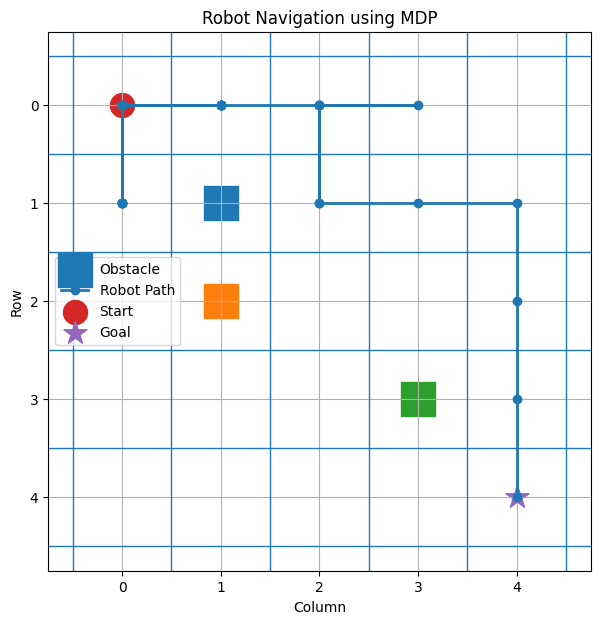

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EXPERIMENT 2: MARKOV DECISION PROCESS (MDP)
# Robot Navigation
# ============================================================

# Grid size
ROWS = 5
COLS = 5

# Start and Goal positions
START = (0, 0)
GOAL = (4, 4)

# Obstacles
OBSTACLES = [(1, 1), (2, 1), (3, 3)]

# Actions
ACTIONS = {
    0: (-1, 0),   # Up
    1: (1, 0),    # Down
    2: (0, -1),   # Left
    3: (0, 1)     # Right
}

ACTION_NAMES = {
    0: "Up",
    1: "Down",
    2: "Left",
    3: "Right"
}


# ============================================================
# TRANSITION FUNCTION
# ============================================================

def get_next_state(state, action):

    row, col = state
    move_row, move_col = ACTIONS[action]

    new_row = row + move_row
    new_col = col + move_col

    # Check grid boundary
    if new_row < 0 or new_row >= ROWS:
        return state

    if new_col < 0 or new_col >= COLS:
        return state

    # Check obstacle
    if (new_row, new_col) in OBSTACLES:
        return state

    return (new_row, new_col)


# ============================================================
# REWARD FUNCTION
# ============================================================

def get_reward(next_state):

    # Goal reached
    if next_state == GOAL:
        return 10

    # Normal movement
    return -1


# ============================================================
# RANDOM ROBOT NAVIGATION
# ============================================================

np.random.seed(42)

state = START
path = [state]
total_reward = 0

print("Robot Navigation")
print("================")

for step in range(50):

    # Choose random action
    action = np.random.randint(4)

    # Find next state
    next_state = get_next_state(state, action)

    # Get reward
    reward = get_reward(next_state)

    print(
        f"Step {step + 1}: "
        f"State={state}, "
        f"Action={ACTION_NAMES[action]}, "
        f"Next State={next_state}, "
        f"Reward={reward}"
    )

    total_reward += reward
    state = next_state
    path.append(state)

    # Stop when goal is reached
    if state == GOAL:
        print("\nGoal Reached!")
        break


print("\nTotal Reward:", total_reward)


# ============================================================
# DISPLAY GRID AND ROBOT PATH
# ============================================================

plt.figure(figsize=(7, 7))

# Draw grid
for i in range(ROWS + 1):
    plt.axhline(i - 0.5, linewidth=1)

for j in range(COLS + 1):
    plt.axvline(j - 0.5, linewidth=1)

# Obstacles
for obstacle in OBSTACLES:
    r, c = obstacle
    plt.scatter(
        c, r,
        s=600,
        marker="s",
        label="Obstacle" if obstacle == OBSTACLES[0] else ""
    )

# Convert path coordinates
path_rows = [p[0] for p in path]
path_cols = [p[1] for p in path]

# Robot path
plt.plot(
    path_cols,
    path_rows,
    marker="o",
    linewidth=2,
    label="Robot Path"
)

# Start
plt.scatter(
    START[1],
    START[0],
    s=300,
    marker="o",
    label="Start"
)

# Goal
plt.scatter(
    GOAL[1],
    GOAL[0],
    s=300,
    marker="*",
    label="Goal"
)

plt.gca().invert_yaxis()

plt.xticks(range(COLS))
plt.yticks(range(ROWS))

plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Robot Navigation using MDP")

plt.legend()
plt.grid(True)

plt.show()